In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action = 'ignore')

plt.style.use("fivethirtyeight")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [5]:
# Read the CSV file
df = pd.read_csv(r"C:/Users/jianc/OneDrive/Desktop/House Price Prediction Dataset.csv")

df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [6]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [7]:
df.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [8]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [10]:
df.columns = df.columns.str.lower()
print("\nNew column names: ")
print(df.columns)


New column names: 
Index(['id', 'area', 'bedrooms', 'bathrooms', 'floors', 'yearbuilt',
       'location', 'condition', 'garage', 'price'],
      dtype='object')


In [11]:
df.describe()

,id,area,bedrooms,bathrooms,floors,yearbuilt,price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [12]:
df.isna().sum()

id           0
area         0
bedrooms     0
bathrooms    0
floors       0
yearbuilt    0
location     0
condition    0
garage       0
price        0
dtype: int64

In [13]:
from datetime import datetime

try:
    df['yearbuilt']= pd.to_datetime(df['yearbuilt'],format='mixed')
    print("All values in 'date' column are valid dates.")
except ValueError as e:
    print("Error:", e)
    print("There are non-date values present in the 'date column.")

All values in 'date' column are valid dates.


In [14]:
# Function to map year to season

def year_to_season(year):

    # Extract month from year string and convert it to integer
    month = datetime.strptime(str(year), '%Y').month

    # Map months to seasons
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        return "Winter"

# Apply year_to_season function to create a new column

df['season'] = df['yearbuilt'].apply(lambda x: year_to_season(x.strftime("%Y")))

In [15]:
# Extract year from the 'yearbuilt' column
df['year'] = df['yearbuilt'].dt.year

# Extract month from the 'yearbuilt' column
df['month'] = df['yearbuilt'].dt.month

# Extract month name from the 'yearbuilt' column
df['month_name'] = df['yearbuilt'].dt.month_name()

# Extract day from the 'yearbuilt' column
df['day'] = df['yearbuilt'].dt.day

# Extract day of the week (0 Monday, 1 Tuesday, ..., 6 Sunday) from the 'yearbuilt' column
df['day_of_week'] = df['yearbuilt'].dt.dayofweek

df.head()

,id,area,bedrooms,bathrooms,floors,yearbuilt,location,condition,garage,price,season,year,month,month_name,day,day_of_week
0,1,1360,5,4,3,1970-01-01 00:00:00.000001970,Downtown,Excellent,No,149919,Winter,1970,1,January,1,3
1,2,4272,5,4,3,1970-01-01 00:00:00.000001958,Downtown,Excellent,No,424998,Winter,1970,1,January,1,3
2,3,3592,2,2,3,1970-01-01 00:00:00.000001938,Downtown,Good,No,266746,Winter,1970,1,January,1,3
3,4,966,4,2,2,1970-01-01 00:00:00.000001902,Suburban,Fair,Yes,244020,Winter,1970,1,January,1,3
4,5,4926,1,4,2,1970-01-01 00:00:00.000001975,Downtown,Fair,Yes,636056,Winter,1970,1,January,1,3


In [16]:
duplicate_values=df.duplicated().sum()
print(f'The data contains {duplicate_values} duplicate values')

The data contains 0 duplicate values


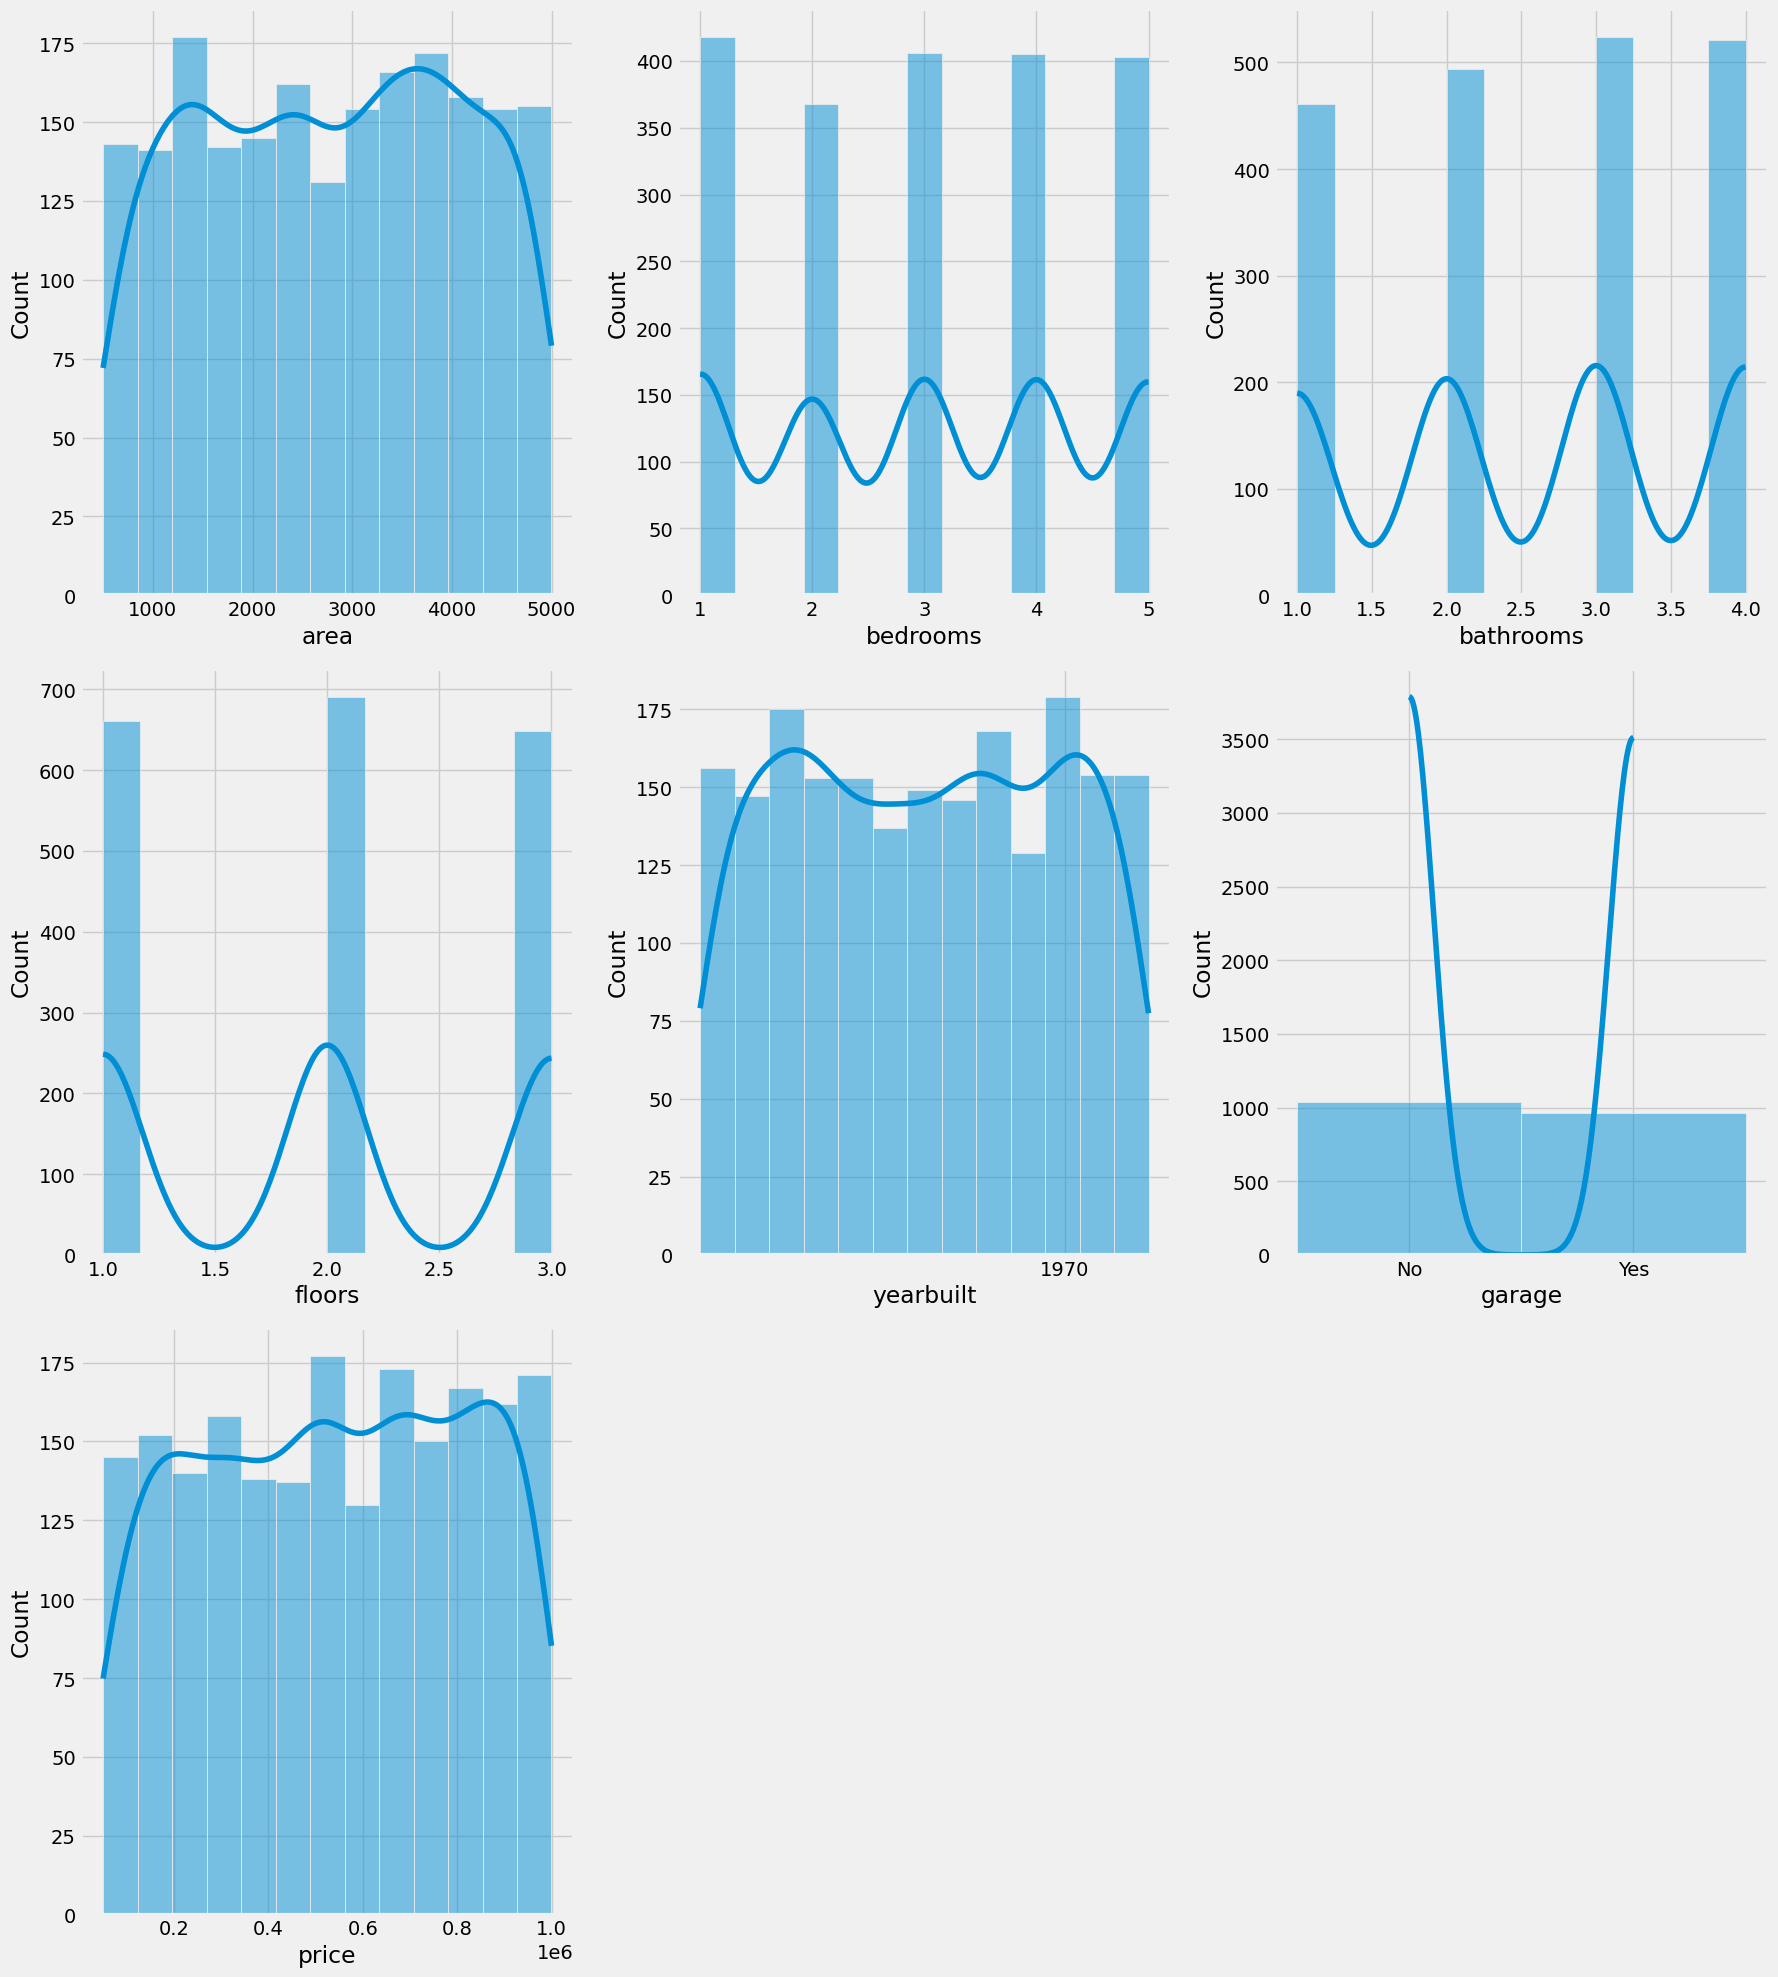

In [17]:
#subplot graph 
features = ['area', 'bedrooms', 'bathrooms', 'floors', 'yearbuilt', 'garage' , 'price']

plt.figure(figsize=(18,20))

for i,col in enumerate(features):

    plt.subplot(3,3, i+1)

    sns.histplot(data=df, x=col, kde=True)

plt.tight_layout()
plt.show()

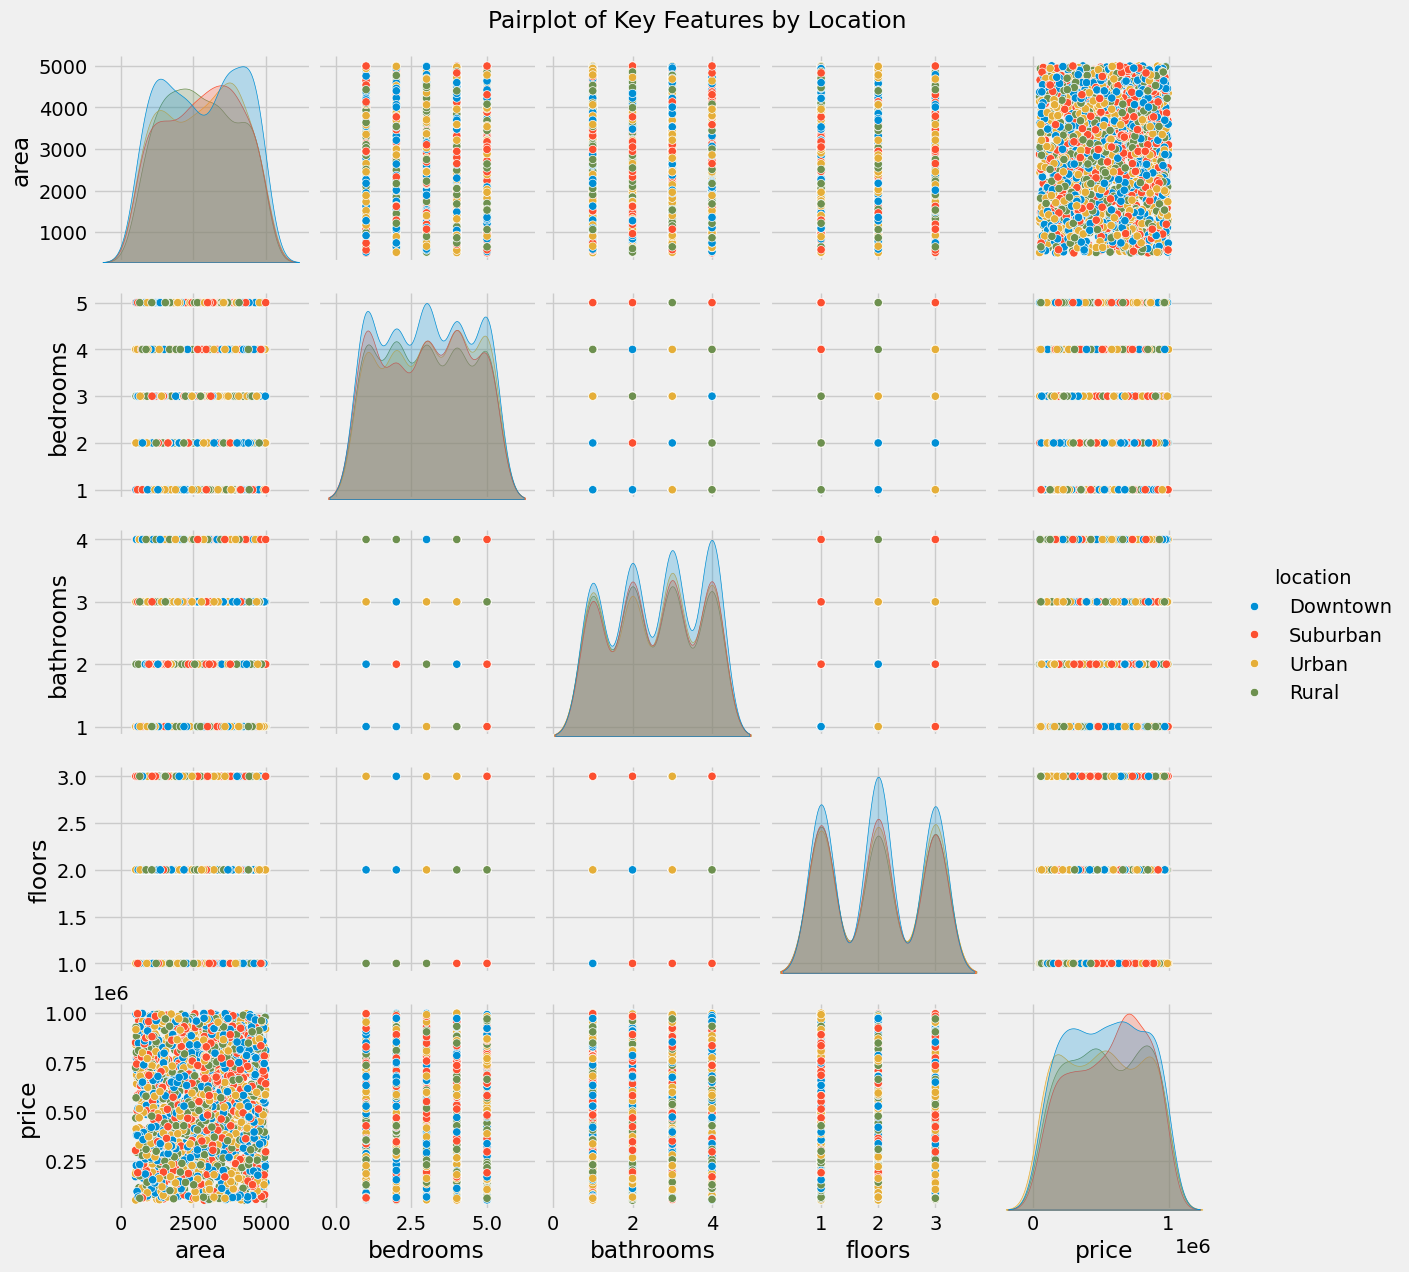

In [18]:
#pairplot
sns.pairplot(df[['area', 'bedrooms', 'bathrooms', 'floors', 'price', 'location']], hue='location')
plt.suptitle('Pairplot of Key Features by Location', y = 1.02) 
plt.show()

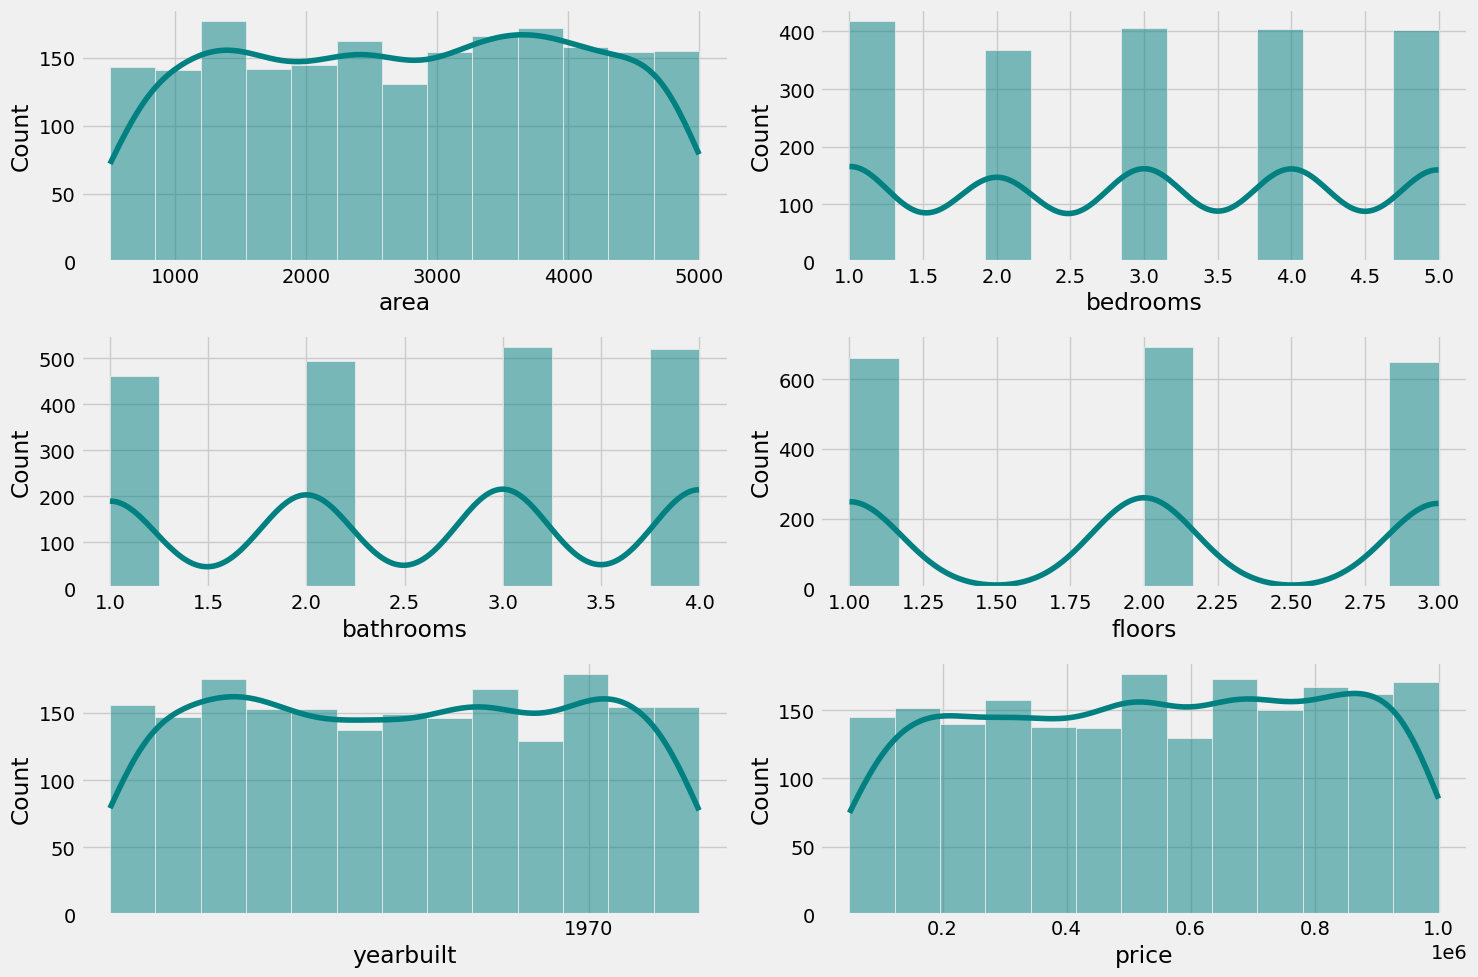

In [19]:
#histogram
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
sns.histplot(df['area'], kde = True, ax = axes[0, 0], color = 'teal')
sns.histplot(df['bedrooms'], kde = True, ax = axes[0, 1], color = 'teal')
sns.histplot(df['bathrooms'], kde = True, ax = axes[1, 0], color = 'teal')
sns.histplot(df['floors'], kde = True, ax = axes[1, 1], color = 'teal')
sns.histplot(df['yearbuilt'], kde = True, ax = axes[2, 0], color = 'teal')
sns.histplot(df['price'], kde = True, ax = axes[2, 1], color = 'teal')
plt.tight_layout()
plt.show()

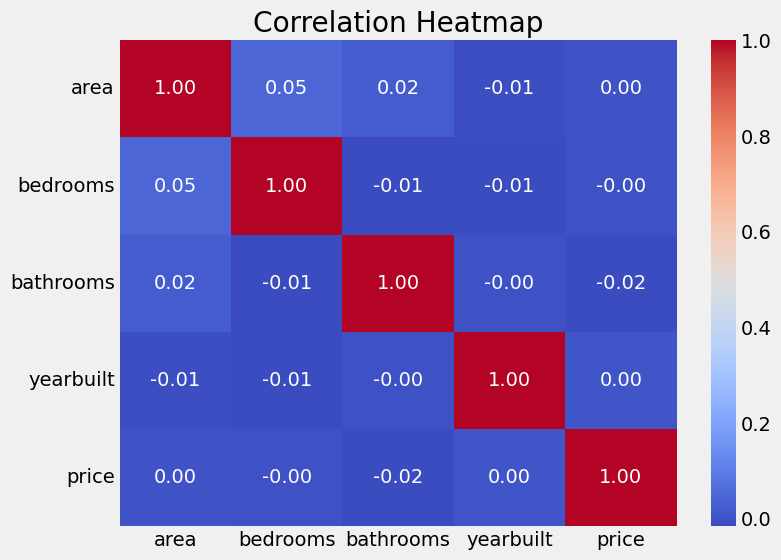

In [34]:
#heatmaps
correlation_matrix = df[['area', 'bedrooms', 'bathrooms', 'yearbuilt', 'price']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()




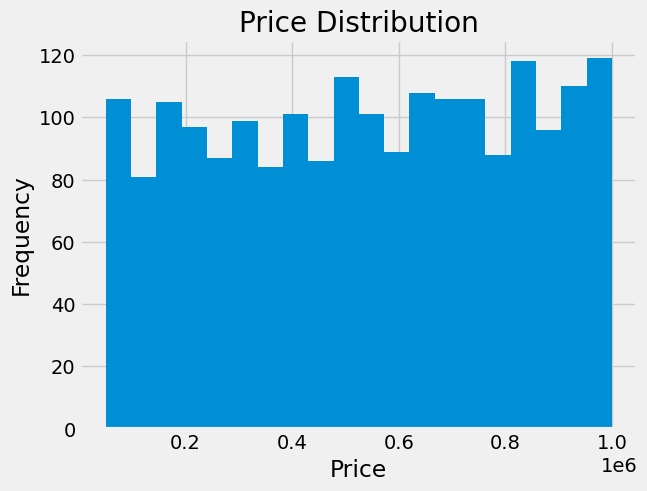

In [21]:
#histogram
plt.hist(df['price'], bins=20)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


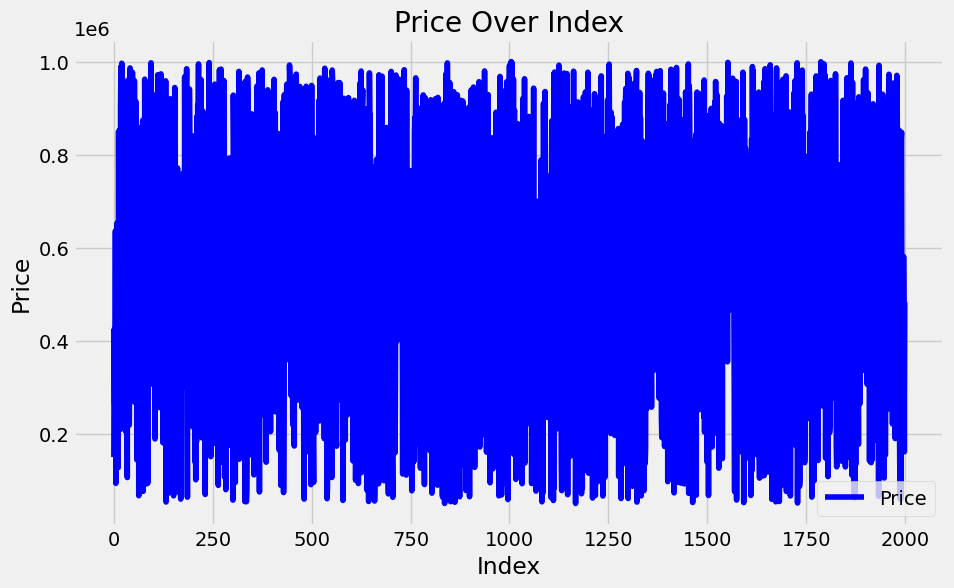

In [22]:
#line charts
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['price'], color='blue', label='Price')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Price Over Index')
plt.legend()
plt.grid(True)
plt.show()

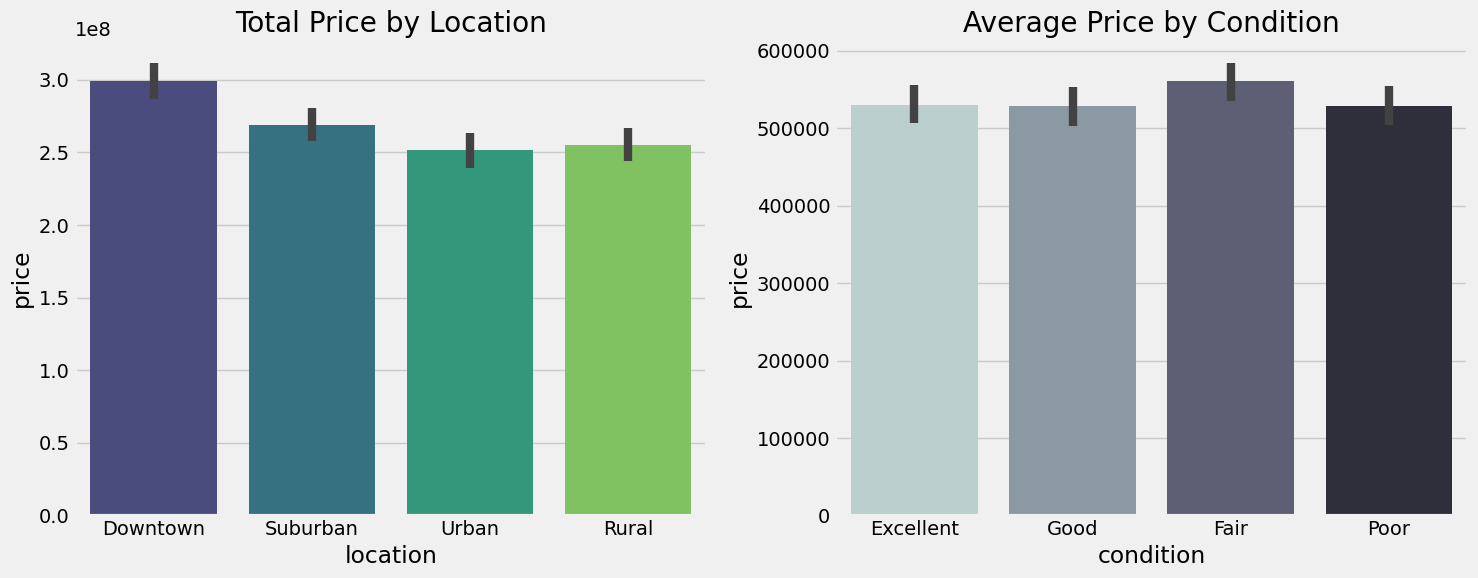

In [23]:
#bar chart
fig, axes = plt.subplots(1, 2, figsize = (15, 6))
sns.barplot(x = 'location', y = 'price', data = df, ax = axes[0], estimator = sum, palette = 'viridis')
axes[0].set_title('Total Price by Location')

sns.barplot(x = 'condition', y = 'price', data = df, ax = axes[1], estimator = np.mean, palette = 'bone_r')
axes[1].set_title('Average Price by Condition')
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# Creating and Displaying the Dataset
# Sample 2: House Price Prediction Reviews
data = {
    'review_text': [
        "This house is beautiful, I love it!",
        "Amazing neighborhood and great design!",
         "Excellent value for the price, highly recommend!",
        "The property is overpriced and small.",
        "The house is old and poorly maintained.",
        "Disappointed with the quality of construction."
    ],
    'sentiment': [
        'positive', 'positive', 'positive', 'negative',
        'negative', 'negative'
    ]
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame(data)

# Display the dataset
print("House Price Prediction Reviews Dataset:")
print(df)

House Price Prediction Reviews Dataset:
                                        review_text sentiment
0               This house is beautiful, I love it!  positive
1            Amazing neighborhood and great design!  positive
2  Excellent value for the price, highly recommend!  positive
3             The property is overpriced and small.  negative
4           The house is old and poorly maintained.  negative
5    Disappointed with the quality of construction.  negative


In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Preprocessing the Dataset
# Vectorize the review text
vectorizer = CountVectorizer(lowercase=True, stop_words='english')
X = vectorizer.fit_transform(df['review_text'])  # Features (vectorized text)
y = df['sentiment']  # Labels (sentiment)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Data Preprocessing Complete.")


Data Preprocessing Complete.


C:\Users\jianc\AppData\Local\Temp\ipykernel_13604\4293131215.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


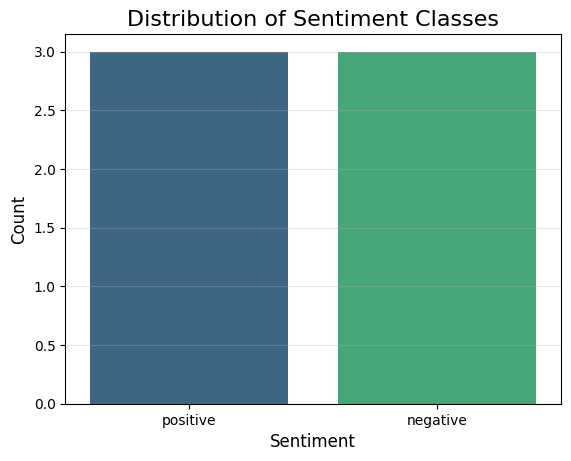

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the class distribution
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiment Classes', fontsize=16)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.show()

Accuracy: 0.50

Classification Report:
              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         1
    positive       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



c:\Users\jianc\OneDrive\Desktop\Notes\SEGi COLLEGE NOTES (DIT)\Introduction to python\PythonApplication1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jianc\OneDrive\Desktop\Notes\SEGi COLLEGE NOTES (DIT)\Introduction to python\PythonApplication1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jianc\OneDrive\Desktop\Notes\SEGi COLLEGE NOTES (DIT)\Introduction to python\PythonApplication1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWar

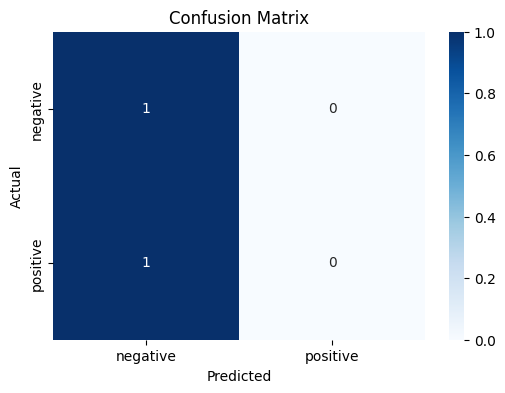

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Implementation Naive Bayes Classifier
# Train the Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
